## Step 0: Importing Necessary Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

# Step 1 loading the data and checking shape structure and preview





In [2]:
customer_df = pd.read_csv('Customer_Master_Data.csv')
transaction_df = pd.read_csv('Customer_Transactions.csv')

# Preview
customer_df.head()


,CustomerID,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate
0,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,22-02-2021
1,CUST10001,Divit Kohli,mkalita@sarin.com,Female,48,Kolkata,Married,0,06-12-2023
2,CUST10002,Kiara Behl,apteanay@hotmail.com,Male,75,Kolkata,Widowed,2,23-08-2023
3,CUST10003,Vaibhav Sankar,bseshadri@choudhry.info,Male,62,Pune,Divorced,2,17-11-2022
4,CUST10004,Shray D’Alia,bdhillon@toor-mall.com,Male,55,Delhi,Divorced,0,04-12-2022


In [3]:
transaction_df.head()


,CustomerID,TransactionDate,TransactionAmount
0,CUST10771,7/31/23,2383.07
1,CUST10100,03-10-2024,497.54
2,CUST10031,2/17/25,536.78
3,CUST10987,7/17/23,314.89
4,CUST10831,12/15/24,2543.19


In [4]:

#shape
customer_df.shape


(1000, 9)

In [5]:
transaction_df.shape

(23050, 3)

In [6]:
#structure
customer_df.info()
transaction_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     1000 non-null   object
 1   Name           1000 non-null   object
 2   Email          1000 non-null   object
 3   Gender         1000 non-null   object
 4   Age            1000 non-null   int64 
 5   City           1000 non-null   object
 6   MaritalStatus  1000 non-null   object
 7   NumChildren    1000 non-null   int64 
 8   JoinDate       1000 non-null   object
dtypes: int64(2), object(7)
memory usage: 70.4+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23050 entries, 0 to 23049
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         23050 non-null  object 
 1   TransactionDate    23050 non-null  object 
 2   TransactionAmount  23050 non-null  float64
dtypes: float64(1), obj

# Step 2- cleaning the data


In [7]:
# Convert date columns to datetime
customer_df['JoinDate'] = pd.to_datetime(
    customer_df['JoinDate'],
    dayfirst=True,
    errors='coerce'
)


transaction_df['TransactionDate'] = pd.to_datetime(
    transaction_df['TransactionDate'],
    dayfirst=False,
    errors='coerce'
)



C:\Users\kshit\AppData\Local\Temp\ipykernel_2012\550935919.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  transaction_df['TransactionDate'] = pd.to_datetime(


In [8]:
customer_df.head()

,CustomerID,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate
0,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22
1,CUST10001,Divit Kohli,mkalita@sarin.com,Female,48,Kolkata,Married,0,2023-12-06
2,CUST10002,Kiara Behl,apteanay@hotmail.com,Male,75,Kolkata,Widowed,2,2023-08-23
3,CUST10003,Vaibhav Sankar,bseshadri@choudhry.info,Male,62,Pune,Divorced,2,2022-11-17
4,CUST10004,Shray D’Alia,bdhillon@toor-mall.com,Male,55,Delhi,Divorced,0,2022-12-04


In [9]:
transaction_df.head()


,CustomerID,TransactionDate,TransactionAmount
0,CUST10771,2023-07-31,2383.07
1,CUST10100,2024-03-10,497.54
2,CUST10031,2025-02-17,536.78
3,CUST10987,2023-07-17,314.89
4,CUST10831,2024-12-15,2543.19


In [10]:
# Ensuring there is no bad data
print("Nulls in Customer Master:")
print(customer_df[['CustomerID', 'JoinDate']].isnull().sum())

print("\nNulls in Transactions:")
print(transaction_df[['CustomerID', 'TransactionDate']].isnull().sum())


Nulls in Customer Master:
CustomerID    0
JoinDate      0
dtype: int64

Nulls in Transactions:
CustomerID         0
TransactionDate    0
dtype: int64


In [11]:
#validating uniqueness of customerID
duplicate_customers = customer_df[customer_df.duplicated('CustomerID', keep=False)]

print(f"Duplicate CustomerIDs: {duplicate_customers.shape[0]}")


Duplicate CustomerIDs: 0


In [12]:
#ensure all transaction cusomer ids exist in master data
# Find transactions with missing customer records
invalid_transactions = transaction_df[
    ~transaction_df['CustomerID'].isin(customer_df['CustomerID'])
]

print(f"Transactions with invalid CustomerID: {invalid_transactions.shape[0]}")


Transactions with invalid CustomerID: 0


In [13]:
print(customer_df.info())
print(transaction_df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   CustomerID     1000 non-null   object        
 1   Name           1000 non-null   object        
 2   Email          1000 non-null   object        
 3   Gender         1000 non-null   object        
 4   Age            1000 non-null   int64         
 5   City           1000 non-null   object        
 6   MaritalStatus  1000 non-null   object        
 7   NumChildren    1000 non-null   int64         
 8   JoinDate       1000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(6)
memory usage: 70.4+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23050 entries, 0 to 23049
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   CustomerID         23050 non-null  o

# Step 3 - Merge the tables


In [14]:
df_merged = transaction_df.merge(
    customer_df,
    on='CustomerID',
    how='left'
)


In [15]:
# verifying if merged properly
print(transaction_df.shape)
print(df_merged.shape)


(23050, 3)
(23050, 11)


# Step 4 RFM Calculation

In [16]:
df_merged['TransactionDate'] = pd.to_datetime(
    df_merged['TransactionDate'], errors='coerce'
)

df_merged['TransactionAmount'] = pd.to_numeric(
    df_merged['TransactionAmount'], errors='coerce'
)


In [17]:
df_merged.shape

(23050, 11)

In [18]:
#dropping NaN rows if any
df_merged = df_merged.dropna(
    subset=['CustomerID', 'TransactionDate', 'TransactionAmount']
)


In [19]:
df_merged.shape

(23050, 11)

In [20]:
#choosing right reference date  ------- instead using ['TransactionDate'].max() find the latest date and minus this date with all dates
reference_date = df_merged['TransactionDate'].max() + pd.Timedelta(days=1)

print("Reference date:", reference_date)


Reference date: 2025-07-30 00:00:00


In [21]:
df_rfm = (
    df_merged
    .groupby('CustomerID')
    .agg(
        Recency=('TransactionDate', lambda x: (reference_date - x.max()).days),
        Frequency=('TransactionDate', 'count'),
        Monetary=('TransactionAmount', 'sum')
    )
    .reset_index()
)


In [22]:
print(df_rfm.head())
print(df_rfm.describe())


  CustomerID  Recency  Frequency  Monetary
0  CUST10000       13         23  21265.49
1  CUST10001       35         30  28654.31
2  CUST10002       18         24  23884.03
3  CUST10003       81         25  24206.03
4  CUST10004        8         19  25565.30
           Recency    Frequency     Monetary
count  1000.000000  1000.000000   1000.00000
mean     50.794000    23.050000  23053.19966
std      58.124418     4.810472   5622.44101
min       1.000000     6.000000   5052.69000
25%      13.000000    20.000000  18965.46250
50%      32.000000    23.000000  22969.82000
75%      69.000000    26.000000  26827.39250
max     524.000000    38.000000  44784.99000


In [23]:
df_merged[df_merged['CustomerID'] == df_rfm.loc[0, 'CustomerID']]


,CustomerID,TransactionDate,TransactionAmount,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate
761,CUST10000,2022-10-03,961.52,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22
2350,CUST10000,2024-05-31,92.16,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22
2608,CUST10000,2024-05-31,1153.74,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22
3847,CUST10000,2023-01-31,1217.04,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22
4308,CUST10000,2022-06-12,912.08,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22
5352,CUST10000,2022-04-21,965.11,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22
5368,CUST10000,2025-07-17,467.93,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22
5541,CUST10000,2025-03-02,1456.19,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22
7460,CUST10000,2024-02-04,1299.42,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22
9992,CUST10000,2024-03-05,1251.68,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22


# Step 5 Score RFM

In [24]:
#recency score
df_rfm['R_Score'] = pd.qcut(
    df_rfm['Recency'].rank(method='first'),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)


In [25]:
#frequency score
df_rfm['F_Score'] = pd.qcut(
    df_rfm['Frequency'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)


In [26]:
#monetory socre
df_rfm['M_Score'] = pd.qcut(
    df_rfm['Monetary'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)


# Step 6 - Create combined RFM Segment

In [27]:
#combine RFM score
df_rfm['RFM_Segment'] = (
    df_rfm['R_Score'].astype(str) +
    df_rfm['F_Score'].astype(str) +
    df_rfm['M_Score'].astype(str)
)


In [28]:
df_rfm[['RFM_Segment']].head()

,RFM_Segment
0,432
1,355
2,433
3,143
4,514


In [29]:
df_rfm['RFM_Segment'].nunique()

108

# Step 7 - assign segment labels

In [30]:
def assign_business_segment(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']

    # Champions
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'

    # Loyal Customers
    elif f >= 4 and r >= 2:
        return 'Loyal Customers'

    # Potential Loyalists
    elif r >= 4 and 2 <= f <= 3:
        return 'Potential Loyalists'

    # Big Spenders
    elif m >= 4 and 2 <= f <= 3 and 3 <= r <= 4:
        return 'Big Spenders'

    # At Risk
    elif r <= 2 and f >= 3:
        return 'At Risk'

    # One-Time / Low Value Users
    elif r <= 2 and f <= 2 and m <= 2:
        return 'One-Time Users'

    # Lost Customers
    elif r == 1 and f <= 2:
        return 'Lost'

    else:
        return 'Needs Attention'


In [31]:
df_rfm['Customer_Segment'] = df_rfm.apply(assign_business_segment, axis=1)


In [32]:
df_rfm['Customer_Segment'].value_counts()


Customer_Segment
Loyal Customers        206
Needs Attention        183
Potential Loyalists    161
At Risk                147
One-Time Users         132
Champions              130
Lost                    24
Big Spenders            17
Name: count, dtype: int64

# Step 8 Visualization

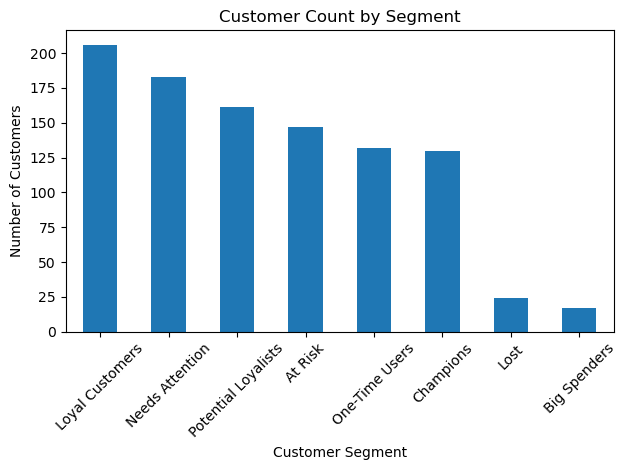

In [33]:
#count of customers in each segment
segment_counts = df_rfm['Customer_Segment'].value_counts()

plt.figure()
segment_counts.plot(kind='bar')
plt.title('Customer Count by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [34]:
#revenue contrubution
customer_revenue = (
    df_merged
    .groupby('CustomerID')['TransactionAmount']
    .sum()
    .reset_index()
)


In [35]:
df_rev_segment = customer_revenue.merge(
    df_rfm[['CustomerID', 'Customer_Segment']],
    on='CustomerID',
    how='left'
)


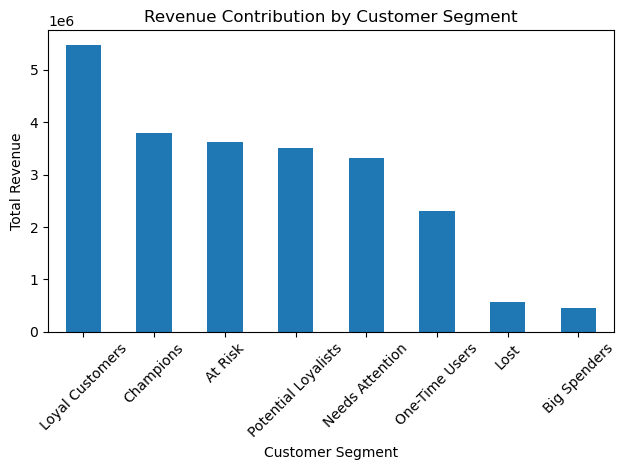

In [36]:
segment_revenue = (
    df_rev_segment
    .groupby('Customer_Segment')['TransactionAmount']
    .sum()
    .sort_values(ascending=False)
)

plt.figure()
segment_revenue.plot(kind='bar')
plt.title('Revenue Contribution by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


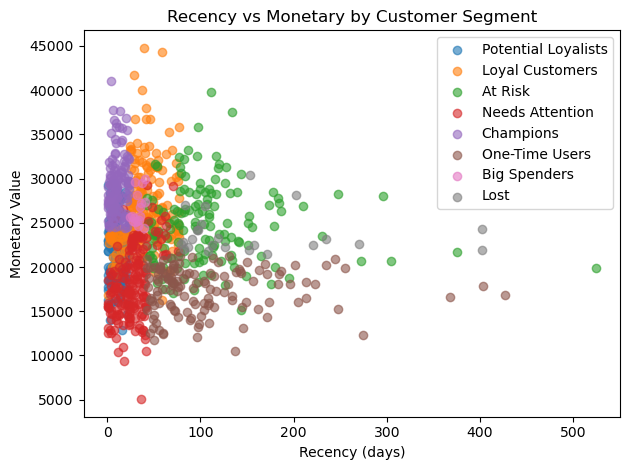

In [37]:
#recency vs monetary
plt.figure()

for segment in df_rfm['Customer_Segment'].unique():
    subset = df_rfm[df_rfm['Customer_Segment'] == segment]
    plt.scatter(
        subset['Recency'],
        subset['Monetary'],
        label=segment,
        alpha=0.6
    )

plt.xlabel('Recency (days)')
plt.ylabel('Monetary Value')
plt.title('Recency vs Monetary by Customer Segment')
plt.legend()
plt.tight_layout()
plt.show()


In [38]:
#pareto analysis
#revenue sort descending
pareto_df = customer_revenue.sort_values(
    by='TransactionAmount',
    ascending=False
).reset_index(drop=True)


In [39]:
#cumulative revenue %
pareto_df['CumulativeRevenue'] = pareto_df['TransactionAmount'].cumsum()
pareto_df['CumulativeRevenuePct'] = (
    pareto_df['CumulativeRevenue'] / pareto_df['TransactionAmount'].sum()
)


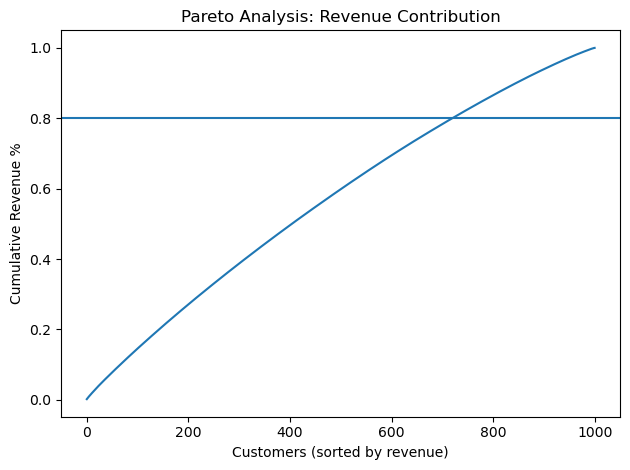

In [40]:
plt.figure()
plt.plot(pareto_df['CumulativeRevenuePct'])
plt.axhline(0.8)
plt.title('Pareto Analysis: Revenue Contribution')
plt.xlabel('Customers (sorted by revenue)')
plt.ylabel('Cumulative Revenue %')
plt.tight_layout()
plt.show()


In [41]:
#identify top 20
top_20_pct_customers = int(0.2 * len(pareto_df))
revenue_share = pareto_df.iloc[:top_20_pct_customers]['TransactionAmount'].sum() / pareto_df['TransactionAmount'].sum()

print(f"Top 20% customers contribute {revenue_share:.2%} of total revenue")


Top 20% customers contribute 27.03% of total revenue
